# 06 — Frequency-domain analysis

Explore frequency-domain differences between real and AI-generated images using train data only. The analysis progresses from individual FFT examples to group mean spectra and image-level radial profile distributions.


## Initial FFT validation

Convert each RGB image to luminance, remove its mean brightness, apply a Hann window to reduce boundary artifacts, and compute the centered log-magnitude spectrum. One real image and one Midjourney image are selected deterministically from the train split. These examples validate the implementation and are not evidence of a class-level difference.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "experiments.yaml").is_file():
            return candidate
    raise FileNotFoundError("Could not find the repository root.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT))

from src.data.config import load_config
from src.features import (
    compute_log_magnitude_spectrum,
    compute_normalized_power_spectrum,
    compute_radial_energy_profile,
    image_to_luminance,
)

config = load_config()
SEED = config["seed"]
MANIFEST_PATH = REPO_ROOT / "data" / "dataset.csv"
PROCESSED_ROOT = REPO_ROOT / "data" / "processed"
RADIAL_BINS = 64

manifest = pd.read_csv(MANIFEST_PATH)
train_rows = manifest[manifest["split"] == "train"].reset_index(drop=True)
frequency_axis = (np.arange(RADIAL_BINS) + 0.5) / RADIAL_BINS
print(f"Train images: {len(train_rows):,}")

Train images: 9,800


In [2]:
manifest = pd.read_csv(MANIFEST_PATH)
train_rows = manifest[manifest["split"] == "train"]

real_row = train_rows[
    (train_rows["label"] == "real")
    & (train_rows["source_group"] == "midjourney")
].sample(
    n=1, random_state=SEED
).iloc[0]
midjourney_row = train_rows[
    (train_rows["label"] == "ai")
    & (train_rows["generator"] == "midjourney")
].sample(n=1, random_state=SEED).iloc[0]

sample_rows = [("Real", real_row), ("Midjourney", midjourney_row)]
[(name, row["filename"]) for name, row in sample_rows]

[('Real', 'real/midjourney__n02097130_5857.jpg'),
 ('Midjourney', 'ai/midjourney__244_midjourney_68.jpg')]

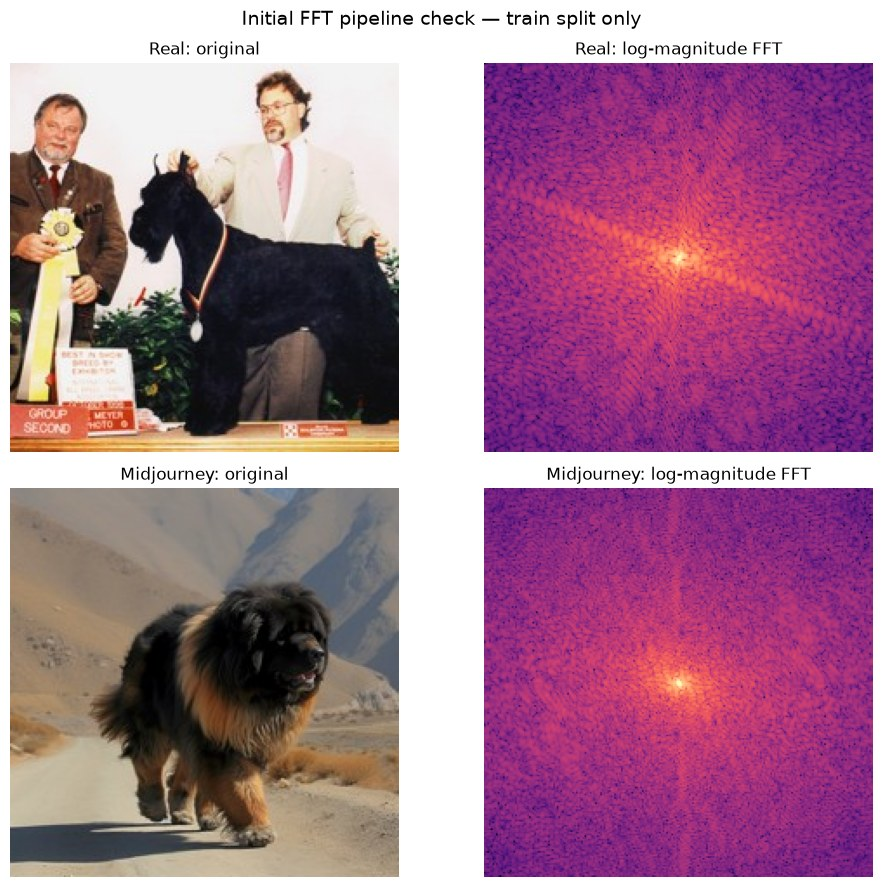

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for row_index, (group_name, row) in enumerate(sample_rows):
    image_path = PROCESSED_ROOT / row["filename"]
    with Image.open(image_path) as source_image:
        image = source_image.convert("RGB").copy()

    luminance = image_to_luminance(image)
    spectrum = compute_log_magnitude_spectrum(luminance)

    axes[row_index, 0].imshow(image)
    axes[row_index, 0].set_title(f"{group_name}: original")
    axes[row_index, 1].imshow(spectrum, cmap="magma")
    axes[row_index, 1].set_title(f"{group_name}: log-magnitude FFT")

for axis in axes.flat:
    axis.axis("off")

fig.suptitle("Initial FFT pipeline check — train split only", fontsize=14)
fig.tight_layout()
plt.show()

## Paired visual check across all generators

Select one AI train image and one real train image from the matching source group for each generator. Pairing by source group makes the comparison more controlled, while the fixed project seed makes it reproducible. Individual examples still cannot establish a generator-level pattern.

In [4]:
paired_rows = []

for generator in config["generators"]:
    real_row = train_rows[
        (train_rows["label"] == "real")
        & (train_rows["source_group"] == generator)
    ].sample(n=1, random_state=SEED).iloc[0]
    ai_row = train_rows[
        (train_rows["label"] == "ai")
        & (train_rows["generator"] == generator)
    ].sample(n=1, random_state=SEED).iloc[0]
    paired_rows.append((generator, real_row, ai_row))

pd.DataFrame(
    [
        {
            "generator": generator,
            "real_image": real_row["filename"],
            "ai_image": ai_row["filename"],
        }
        for generator, real_row, ai_row in paired_rows
    ]
)

,generator,real_image,ai_image
0,biggan,real/biggan__n02229544_6967.jpg,ai/biggan__599_biggan_00012.jpg
1,glide,real/glide__n02395406_7894.jpg,ai/glide__GLIDE_1000_200_08_816_glide_00114.jpg
2,vqdm,real/vqdm__n07248320_6595.jpg,ai/vqdm__VQDM_1000_200_00_055_vqdm_00085.jpg
3,sdv1_5,real/sdv1_5__n02607072_3399.jpg,ai/sdv1_5__800_sdv5_00040.jpg
4,adm,real/adm__n02094258_5939.jpg,ai/adm__774_adm_61.jpg
5,midjourney,real/midjourney__n02097130_5857.jpg,ai/midjourney__244_midjourney_68.jpg
6,wukong,real/wukong__n02422106_418.jpg,ai/wukong__103_wukong_image81.jpg


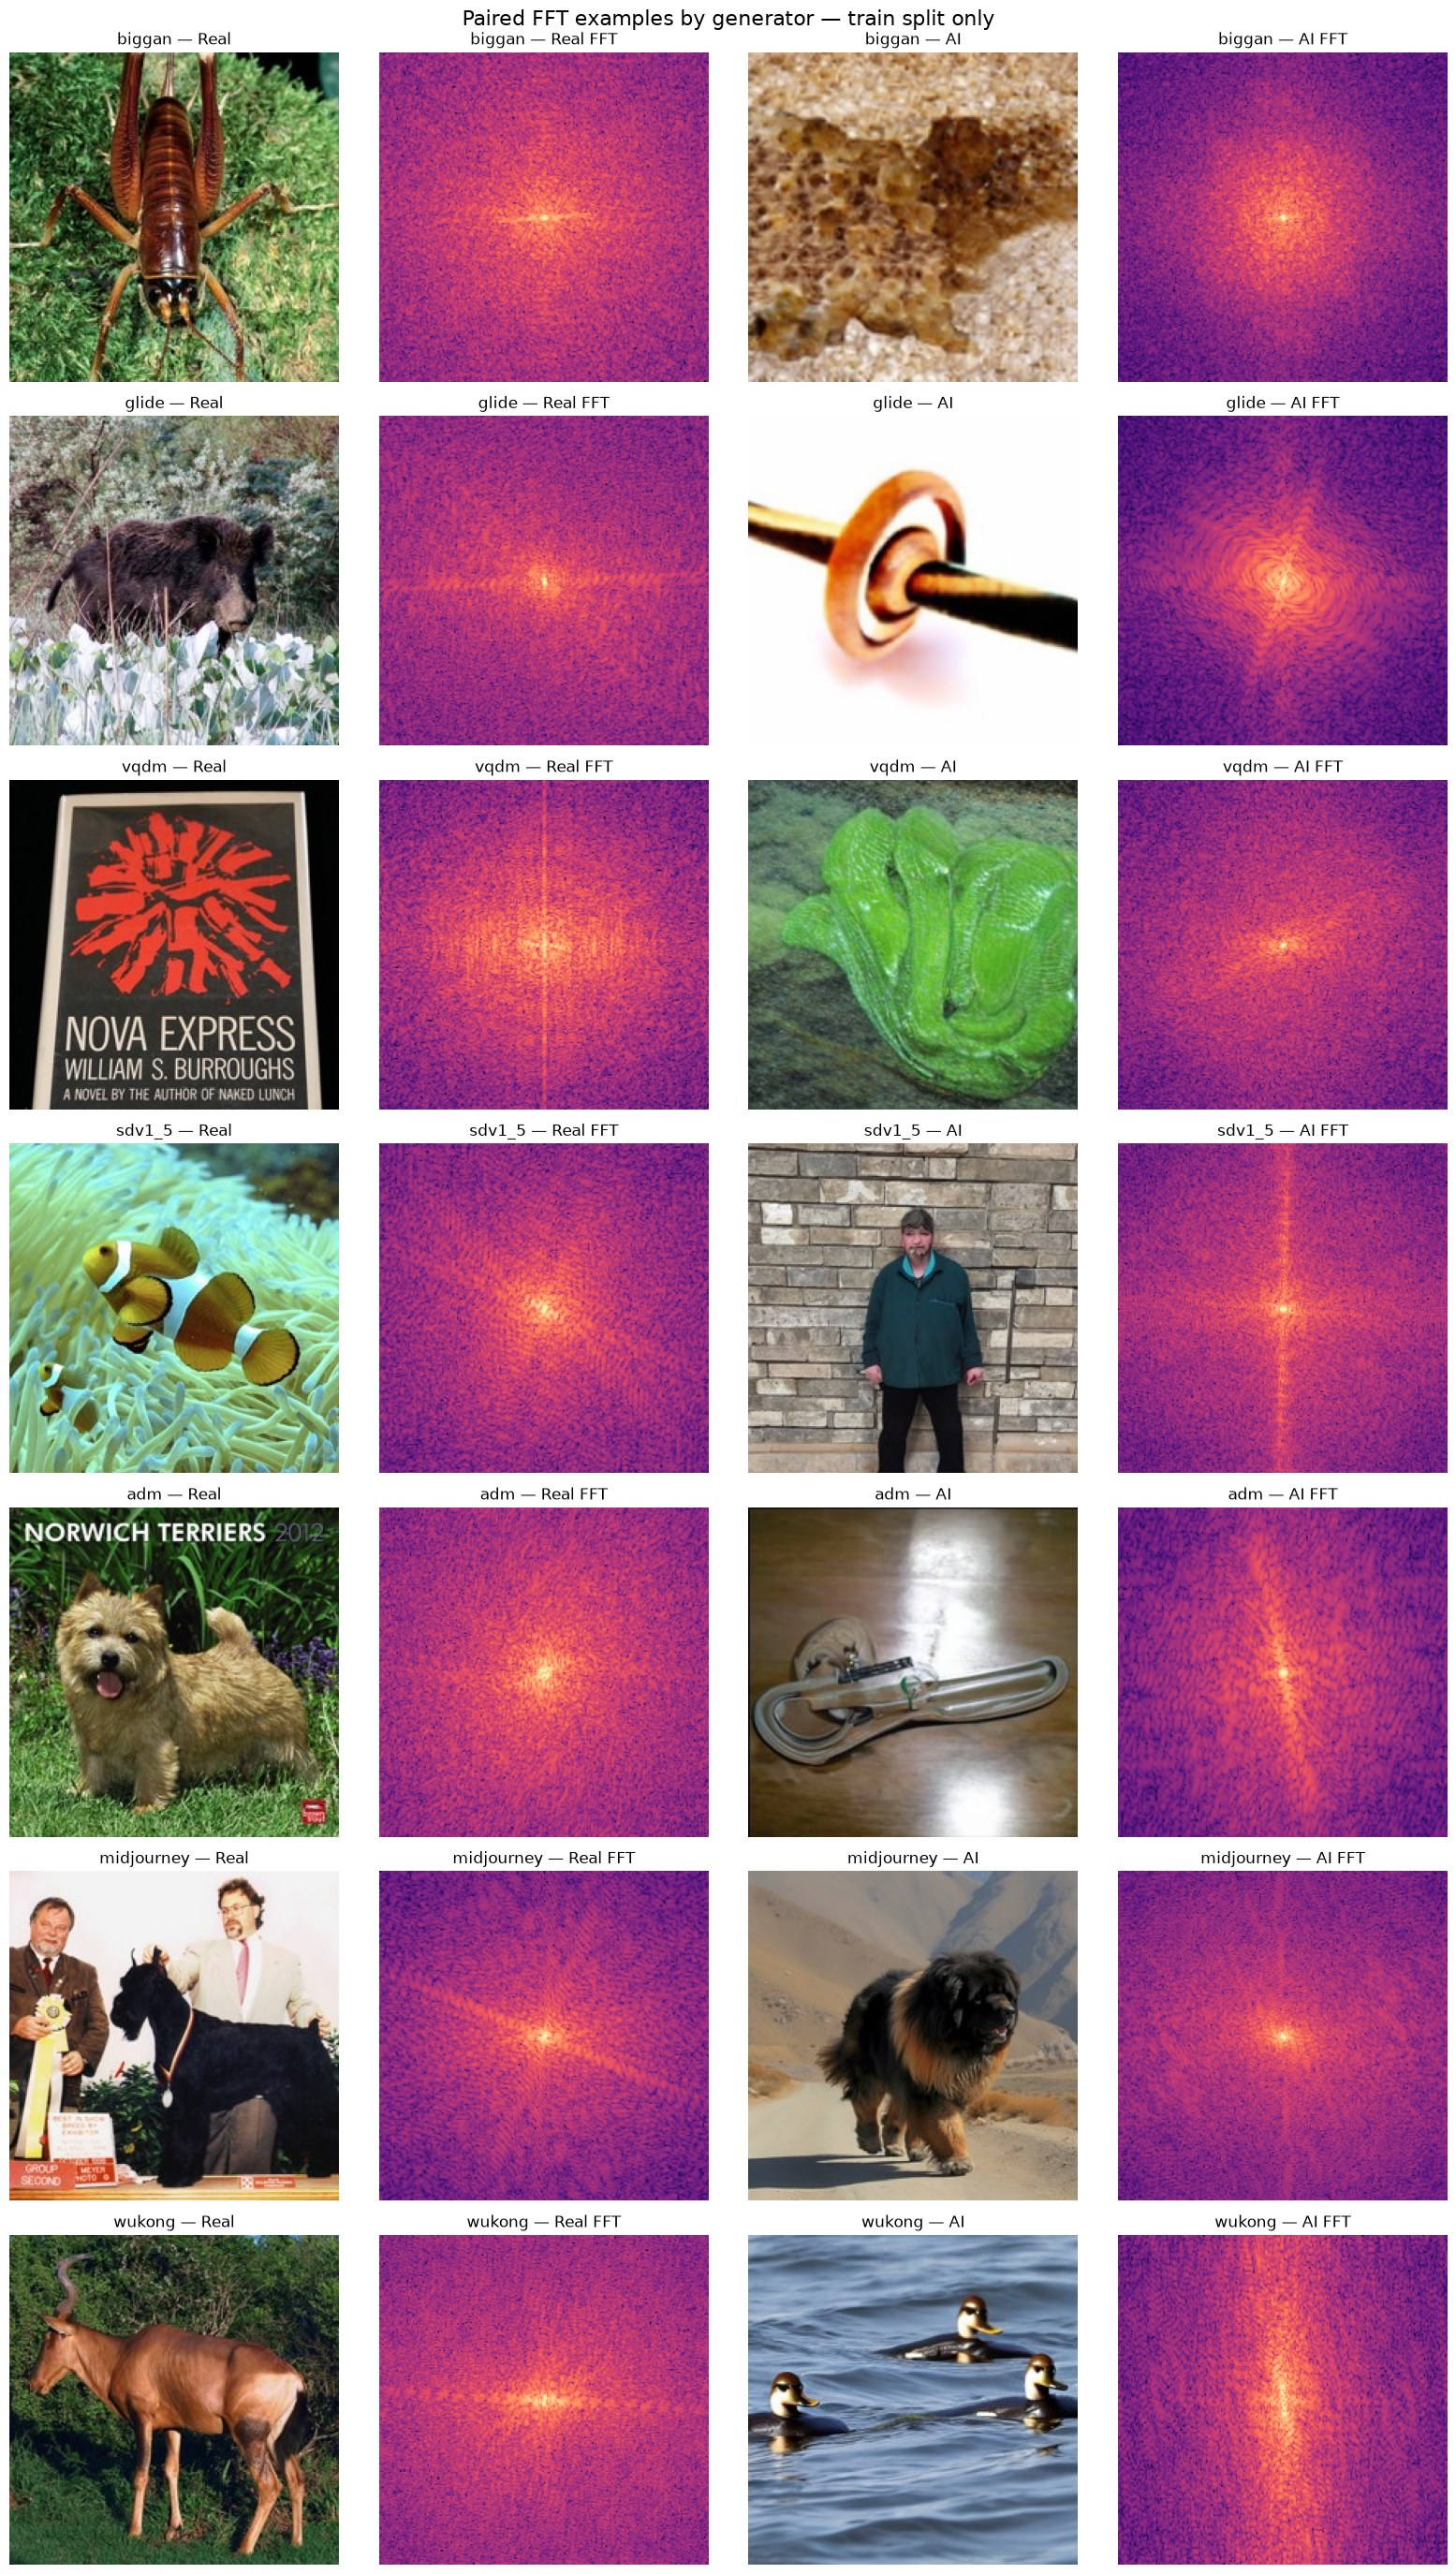

In [5]:
fig, axes = plt.subplots(len(paired_rows), 4, figsize=(16, 4 * len(paired_rows)))

for row_index, (generator, real_row, ai_row) in enumerate(paired_rows):
    for column_offset, (label, sample_row) in enumerate(
        (("Real", real_row), ("AI", ai_row))
    ):
        image_path = PROCESSED_ROOT / sample_row["filename"]
        with Image.open(image_path) as source_image:
            image = source_image.convert("RGB").copy()

        spectrum = compute_log_magnitude_spectrum(image_to_luminance(image))
        image_axis = axes[row_index, column_offset * 2]
        spectrum_axis = axes[row_index, column_offset * 2 + 1]

        image_axis.imshow(image)
        image_axis.set_title(f"{generator} — {label}")
        spectrum_axis.imshow(spectrum, cmap="magma")
        spectrum_axis.set_title(f"{generator} — {label} FFT")

for axis in axes.flat:
    axis.axis("off")

fig.suptitle("Paired FFT examples by generator — train split only", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.99))
plt.show()

## Interpretation boundary

The spectra above are technical and visual sanity checks. A difference between individual images may come from image content rather than image origin. Each spectrum is also color-scaled independently, so colors cannot be used to compare absolute energy between panels. Group-level averages, radial profiles, and numerical comparisons are required before drawing conclusions about real images or any generator.

## Group-level mean power spectra

Average normalized FFT power across all train images for each generator and its matched real source group.


In [6]:
def mean_normalized_power(rows: pd.DataFrame) -> np.ndarray:
    """Average unit-energy power spectra for the supplied manifest rows."""
    if rows.empty:
        raise ValueError("Cannot average an empty image group.")

    accumulator = None
    for filename in rows["filename"]:
        image_path = PROCESSED_ROOT / filename
        with Image.open(image_path) as image:
            luminance = image_to_luminance(image)
        power = compute_normalized_power_spectrum(luminance)

        if accumulator is None:
            accumulator = np.zeros_like(power, dtype=np.float64)
        accumulator += power

    return accumulator / len(rows)


In [7]:
mean_power_by_generator = {}
group_counts = []

for generator in config["generators"]:
    real_rows = train_rows[
        (train_rows["label"] == "real")
        & (train_rows["source_group"] == generator)
    ]
    ai_rows = train_rows[
        (train_rows["label"] == "ai")
        & (train_rows["generator"] == generator)
    ]

    print(f"Processing {generator}: {len(real_rows)} real + {len(ai_rows)} AI")
    mean_power_by_generator[generator] = {
        "real": mean_normalized_power(real_rows),
        "ai": mean_normalized_power(ai_rows),
    }
    group_counts.append(
        {"generator": generator, "n_real": len(real_rows), "n_ai": len(ai_rows)}
    )

group_counts = pd.DataFrame(group_counts)
display(group_counts)

Processing biggan: 700 real + 700 AI
Processing glide: 700 real + 700 AI
Processing vqdm: 700 real + 700 AI
Processing sdv1_5: 700 real + 700 AI
Processing adm: 700 real + 700 AI
Processing midjourney: 700 real + 700 AI
Processing wukong: 700 real + 700 AI


,generator,n_real,n_ai
0,biggan,700,700
1,glide,700,700
2,vqdm,700,700
3,sdv1_5,700,700
4,adm,700,700
5,midjourney,700,700
6,wukong,700,700


## Mean spectra and AI-to-real differences

Real and AI panels within each row use the same color scale. The difference panel shows `log10(AI power) - log10(real power)`: red regions contain relatively more average AI power, while blue regions contain relatively more average real power.

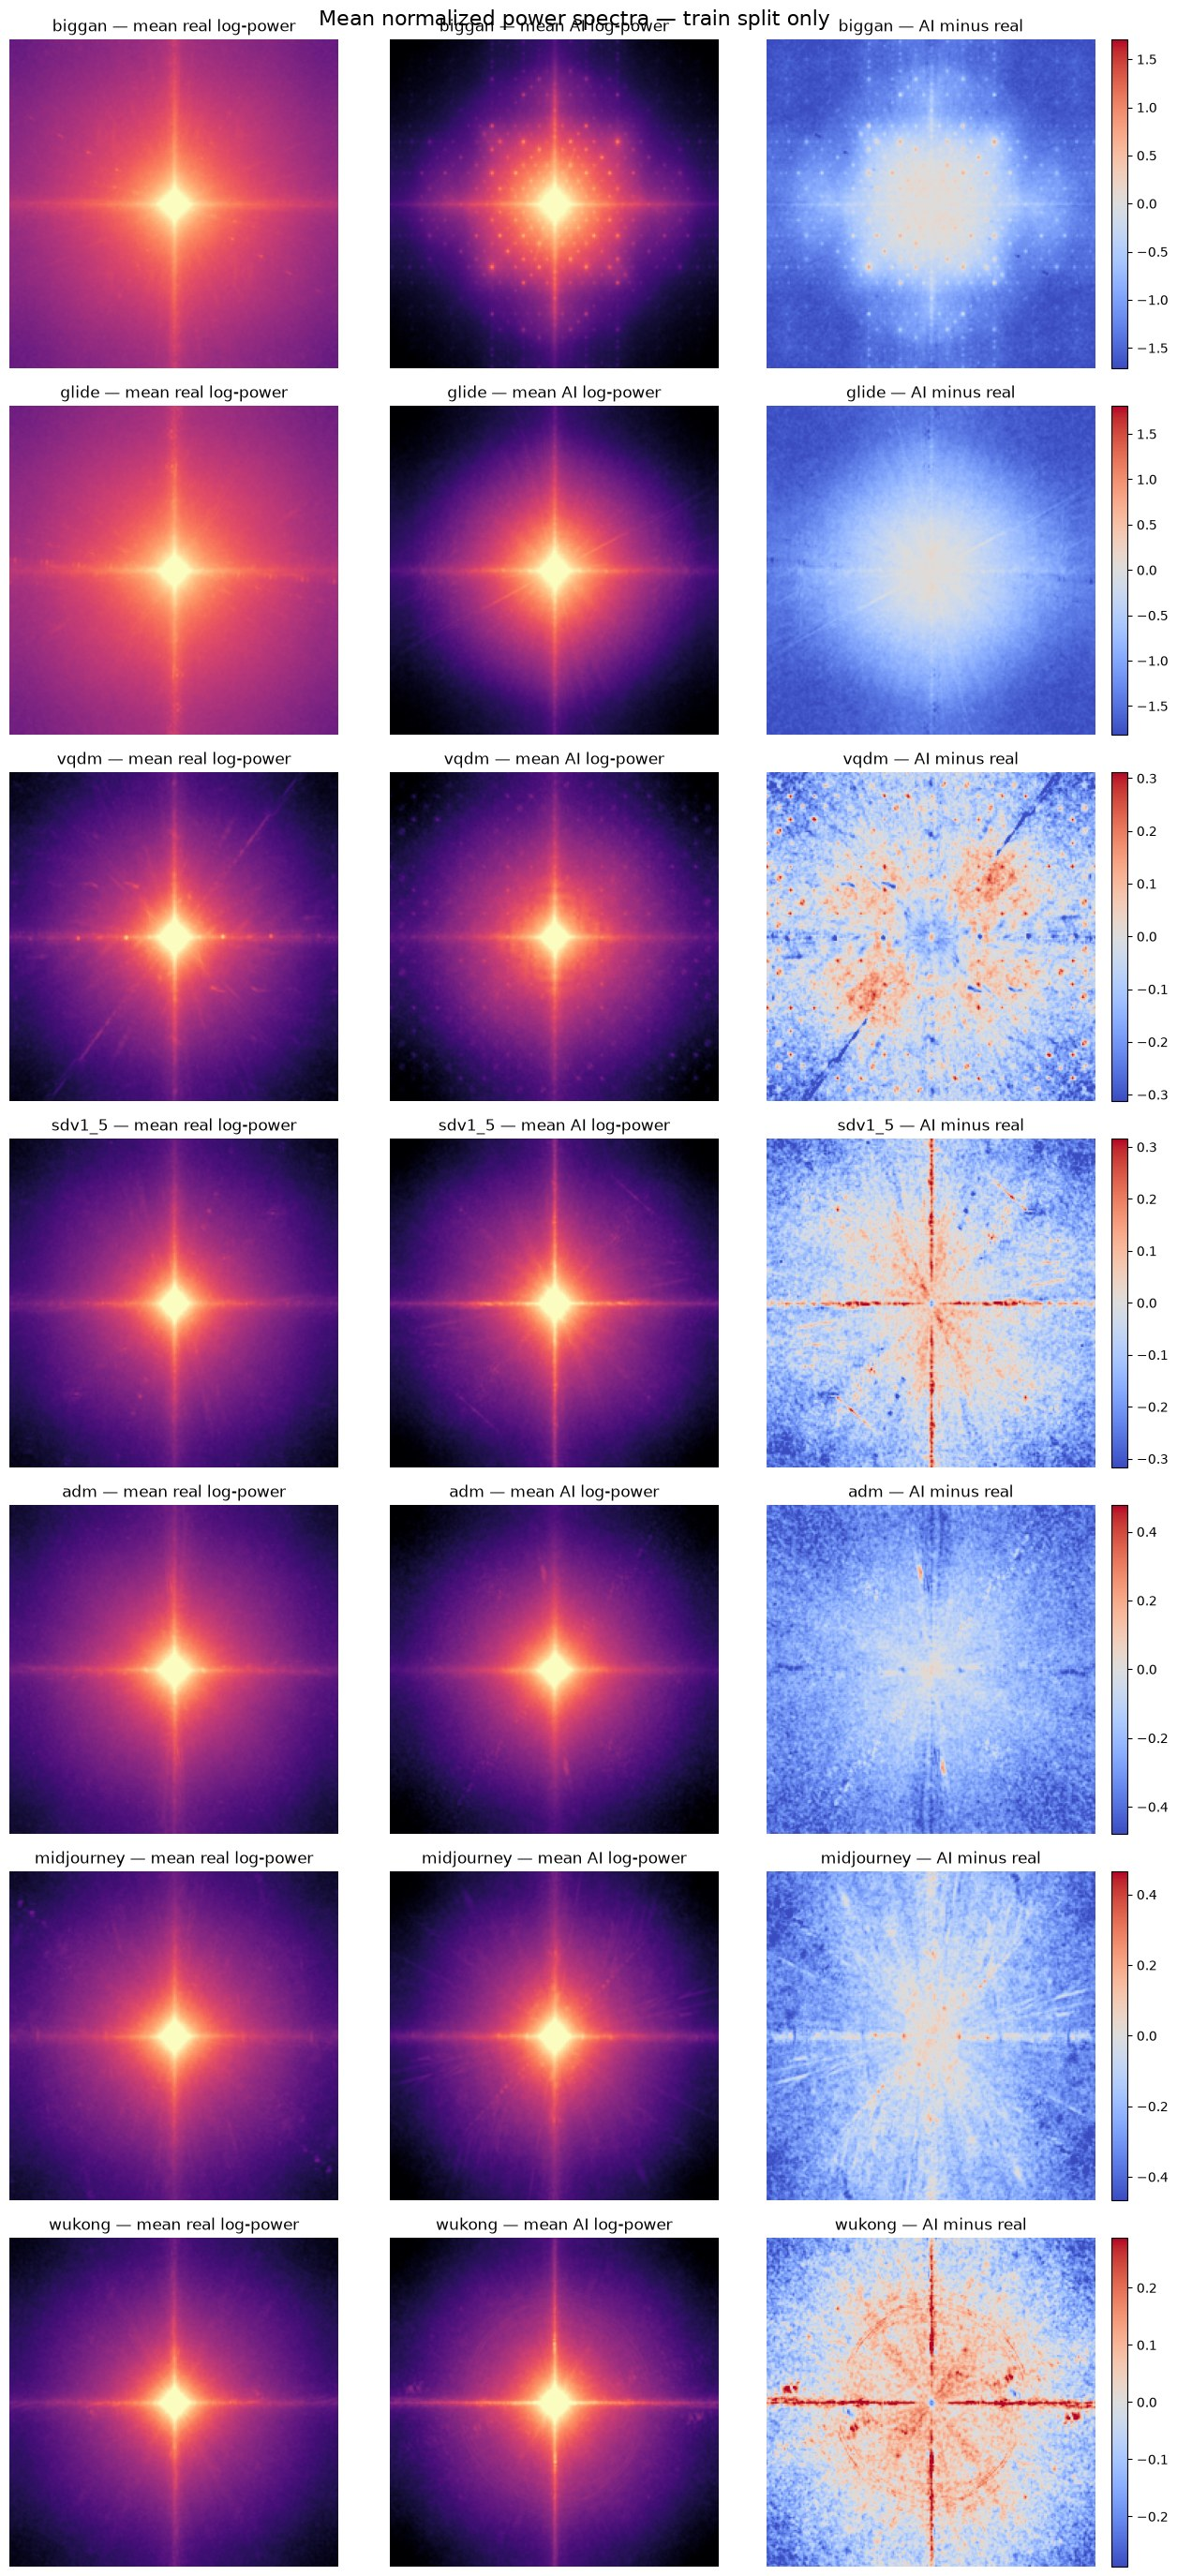

In [8]:
epsilon = 1e-12
generators = config["generators"]
fig, axes = plt.subplots(len(generators), 3, figsize=(13, 4 * len(generators)))

for row_index, generator in enumerate(generators):
    real_log_power = np.log10(mean_power_by_generator[generator]["real"] + epsilon)
    ai_log_power = np.log10(mean_power_by_generator[generator]["ai"] + epsilon)
    combined = np.concatenate((real_log_power.ravel(), ai_log_power.ravel()))
    shared_min, shared_max = np.percentile(combined, (1, 99.5))

    axes[row_index, 0].imshow(
        real_log_power, cmap="magma", vmin=shared_min, vmax=shared_max
    )
    axes[row_index, 1].imshow(
        ai_log_power, cmap="magma", vmin=shared_min, vmax=shared_max
    )

    difference = ai_log_power - real_log_power
    difference_limit = np.percentile(np.abs(difference), 99)
    difference_image = axes[row_index, 2].imshow(
        difference,
        cmap="coolwarm",
        vmin=-difference_limit,
        vmax=difference_limit,
    )

    axes[row_index, 0].set_title(f"{generator} — mean real log-power")
    axes[row_index, 1].set_title(f"{generator} — mean AI log-power")
    axes[row_index, 2].set_title(f"{generator} — AI minus real")
    fig.colorbar(difference_image, ax=axes[row_index, 2], fraction=0.046, pad=0.04)

for axis in axes.flat:
    axis.axis("off")

fig.suptitle("Mean normalized power spectra — train split only", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.995))
plt.show()

## Radial frequency profiles

Measure how normalized FFT energy is distributed from low to high spatial frequencies for every train image.


## Method

Divide the centered power spectrum into 64 concentric annuli within the largest fully supported circle. Sum the normalized power in each annulus and renormalize the resulting profile to one. Frequency 0 represents the center/lowest frequencies and frequency 1 the edge/highest axis-aligned frequencies.

In [9]:
def radial_profiles(rows: pd.DataFrame) -> np.ndarray:
    """Calculate one normalized radial energy profile per image."""
    if rows.empty:
        raise ValueError("Cannot calculate profiles for an empty group.")

    profiles = np.empty((len(rows), RADIAL_BINS), dtype=np.float32)
    for index, filename in enumerate(rows["filename"]):
        image_path = PROCESSED_ROOT / filename
        with Image.open(image_path) as image:
            luminance = image_to_luminance(image)
        power = compute_normalized_power_spectrum(luminance)
        profiles[index] = compute_radial_energy_profile(
            power, bins=RADIAL_BINS
        )

    return profiles


In [10]:
profiles_by_generator = {}

for generator in config["generators"]:
    real_rows = train_rows[
        (train_rows["label"] == "real")
        & (train_rows["source_group"] == generator)
    ]
    ai_rows = train_rows[
        (train_rows["label"] == "ai")
        & (train_rows["generator"] == generator)
    ]

    print(f"Processing {generator}: {len(real_rows)} real + {len(ai_rows)} AI")
    profiles_by_generator[generator] = {
        "real": radial_profiles(real_rows),
        "ai": radial_profiles(ai_rows),
    }


Processing biggan: 700 real + 700 AI
Processing glide: 700 real + 700 AI
Processing vqdm: 700 real + 700 AI
Processing sdv1_5: 700 real + 700 AI
Processing adm: 700 real + 700 AI
Processing midjourney: 700 real + 700 AI
Processing wukong: 700 real + 700 AI


## Image-level profile distributions

Solid lines show the median profile. Shaded regions span the 25th to 75th percentiles across individual images, revealing typical image-to-image variability rather than uncertainty of the group mean. A logarithmic y-axis makes low-energy high-frequency bands visible.

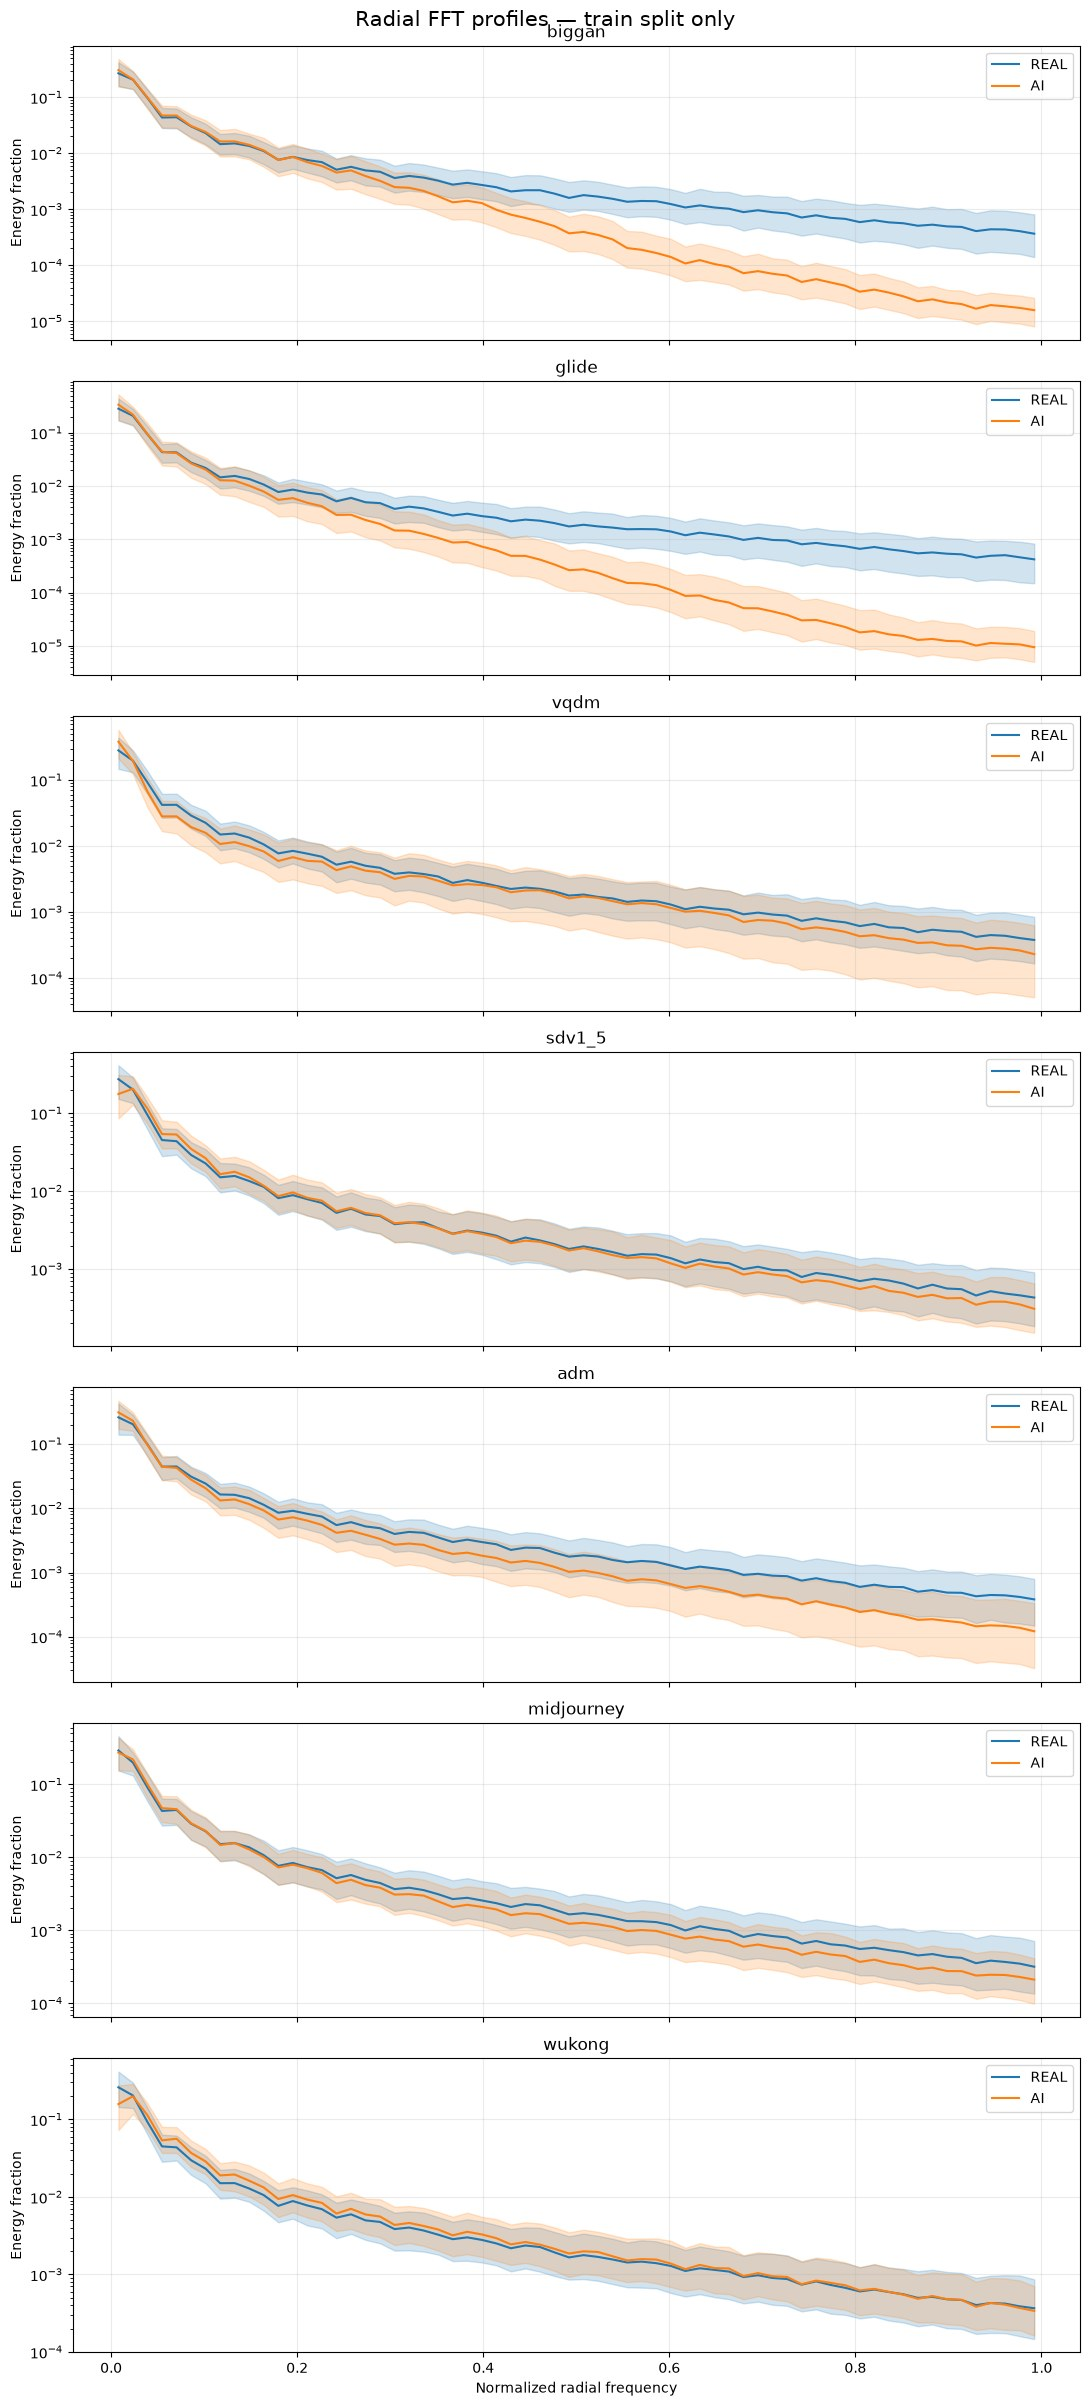

In [11]:
generators = config["generators"]
fig, axes = plt.subplots(len(generators), 1, figsize=(11, 3.5 * len(generators)), sharex=True)
minimum_display_energy = 1e-8

for axis, generator in zip(axes, generators):
    for label, color in (("real", "tab:blue"), ("ai", "tab:orange")):
        profiles = profiles_by_generator[generator][label]
        lower, median, upper = np.percentile(profiles, (25, 50, 75), axis=0)
        median = np.maximum(median, minimum_display_energy)
        lower = np.maximum(lower, minimum_display_energy)
        upper = np.maximum(upper, minimum_display_energy)

        axis.plot(frequency_axis, median, color=color, label=label.upper())
        axis.fill_between(frequency_axis, lower, upper, color=color, alpha=0.2)

    axis.set_yscale("log")
    axis.set_title(generator)
    axis.set_ylabel("Energy fraction")
    axis.grid(alpha=0.25)
    axis.legend()

axes[-1].set_xlabel("Normalized radial frequency")
fig.suptitle("Radial FFT profiles — train split only", fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.995))
plt.show()

## Descriptive separation of mean profiles

Total variation distance compares the two mean radial distributions. It ranges from 0 for identical mean profiles to 1 for non-overlapping profiles. This is a descriptive train-set statistic, not classifier performance or a statistical significance test.

In [12]:
separation_rows = []

for generator in config["generators"]:
    mean_real = profiles_by_generator[generator]["real"].mean(axis=0)
    mean_ai = profiles_by_generator[generator]["ai"].mean(axis=0)
    total_variation = 0.5 * np.abs(mean_ai - mean_real).sum()
    separation_rows.append(
        {"generator": generator, "profile_total_variation": total_variation}
    )

profile_separation = pd.DataFrame(separation_rows).sort_values(
    "profile_total_variation", ascending=False
).reset_index(drop=True)
display(profile_separation)

,generator,profile_total_variation
0,wukong,0.114576
1,vqdm,0.093409
2,sdv1_5,0.089346
3,glide,0.082012
4,adm,0.063034
5,biggan,0.058763
6,midjourney,0.041693


## Interpretation boundary

Radial averaging intentionally removes directional patterns such as the BigGAN grid or the SD v1.5 cross. It therefore complements, rather than replaces, the two-dimensional mean spectra. The profiles describe train data only and must not be reported as validation or test performance.